<a href="https://colab.research.google.com/github/ShatohinaYelizaveta/Notes_app_Django/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧪 Домашнє завдання 3 — Якість даних та виявлення дрейфу

---

> 📌 **Сценарій:** Ви — AI QA-інженер у retail-компанії.  
> Команда підтримує **модель прогнозування відтоку клієнтів (churn prediction)**.  
> Модель навчалась на даних **Q1 2024 (reference period)** і зараз працює з даними **Q4 2024 (production)**.  
> Ваше завдання — відповісти перед командою:  
> **«Чи безпечно довіряти поточним передбаченням моделі — і чому?»**

---

| Параметр | Деталі |
|---|---|
| Датасет | Синтетичні дані клієнтської бази (генерується в ноутбуці) |
| Reference | Q1 2024 — дані, на яких навчалась модель |
| Current | Q4 2024 — поточний продакшн-потік |
| Мета | Виявити дрейф, валідувати якість даних, підготувати звіт |

---

### 🗺️ Структура ноутбука

| Крок | Тема | Концепт з лекції |
|---|---|---|
| 0 | Встановлення та імпорти | — |
| 1 | Генерація датасету та базовий EDA | Розподіли, категорії якості |
| 2 | Валідація якості даних | Schema, outliers, duplicates, missing values |
| 3 | Симуляція сценаріїв дрейфу | Data drift, Concept drift, Label drift |
| 4 | Evidently AI: drift report | DataDriftPreset, DataQualityPreset |
| 5 | Поглиблений аналіз дрейфу | PSI, KS-test, Chi-squared |
| 6 | OOD-детекція | Mahalanobis distance, Confidence threshold |
| 7 | Фінальний висновок QA-інженера | — |


---
## ⚙️ Крок 0 — Встановлення та імпорти

> 💡 **Теорія:** В цьому завданні ми використовуємо **Evidently AI** — open-source платформу  
> для моніторингу ML-моделей, яка спеціалізується на виявленні дрейфу та деградації якості даних.  
> Також використовуємо стандартні статистичні тести для ручної перевірки.


In [4]:
!pip install evidently==0.4.40

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.2/579.2 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 74.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import mahalanobis

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score

# Evidently AI — core
from evidently.report import Report
from evidently.test_suite import TestSuite
from evidently.pipeline.column_mapping import ColumnMapping

# Presets  (high-level, run many metrics at once)
from evidently.metric_preset import DataDriftPreset, DataQualityPreset, TargetDriftPreset

# Individual metrics  (fine-grained control)
from evidently.metrics import (
    DatasetDriftMetric,
    ColumnDriftMetric,
    ColumnSummaryMetric,
)

# Test presets & individual tests  (CI/CD gates)
from evidently.test_preset import DataDriftTestPreset, DataQualityTestPreset
from evidently.tests import TestColumnDrift, TestShareOfDriftedColumns

np.random.seed(42)
print('✅ Всі бібліотеки успішно завантажено')
import evidently; print(f'   evidently version: {evidently.__version__}')


✅ Всі бібліотеки успішно завантажено
   evidently version: 0.4.40


---
## 📊 Крок 1 — Генерація датасету та базовий EDA

### 🎓 Теорія: Структура даних для churn-моделі

З **Лекції 6** ми знаємо, що якість даних — основа якості моделі.  
Перш ніж шукати дрейф, потрібно зрозуміти **нормальний стан** (reference distribution).

**Ознаки клієнта:**

| Feature | Тип | Опис |
|---|---|---|
| `age` | Числова | Вік клієнта |
| `monthly_spend` | Числова | Середні витрати на місяць (USD) |
| `tenure_months` | Числова | Термін клієнтства (місяців) |
| `support_tickets` | Числова | Кількість звернень у підтримку |
| `region` | Категоріальна | Регіон: North / South / East / West |
| `subscription_type` | Категоріальна | Basic / Premium / Enterprise |
| `churn` | Ціль (бінарна) | 1 = відтік, 0 = залишився |


In [6]:
# ── 1а. Генерація reference-датасету (Q1 2024) ──────────────────────────────
N_REF = 1000  # розмір reference вибірки

def generate_reference_data(n, seed=42):
    rng = np.random.default_rng(seed)
    age             = rng.normal(38, 10, n).clip(18, 75).astype(int)
    monthly_spend   = rng.normal(120, 40, n).clip(10, 500).round(2)
    tenure_months   = rng.exponential(24, n).clip(1, 120).astype(int)
    support_tickets = rng.poisson(1.5, n)
    region          = rng.choice(['North','South','East','West'], n, p=[0.3,0.25,0.25,0.2])
    sub_type        = rng.choice(['Basic','Premium','Enterprise'], n, p=[0.5,0.35,0.15])

    # Churn залежить від tenure, spend та support_tickets
    churn_prob = (
        0.05
        + 0.15 * (tenure_months < 6)
        + 0.10 * (monthly_spend < 60)
        + 0.12 * (support_tickets >= 3)
        - 0.08 * (sub_type == 'Enterprise')
    )
    churn = (rng.uniform(0, 1, n) < churn_prob).astype(int)

    return pd.DataFrame({
        'age': age, 'monthly_spend': monthly_spend,
        'tenure_months': tenure_months, 'support_tickets': support_tickets,
        'region': region, 'subscription_type': sub_type, 'churn': churn
    })

reference_df = generate_reference_data(N_REF)

print("=== Reference Dataset (Q1 2024) ===")
print(f"Розмір: {reference_df.shape[0]} рядків × {reference_df.shape[1]} колонок")
print(f"\nРозподіл churn:")
churn_counts = reference_df['churn'].value_counts()
print(f"  Залишились (0): {churn_counts[0]:4d}  ({churn_counts[0]/N_REF:.1%})")
print(f"  Відтік    (1): {churn_counts[1]:4d}  ({churn_counts[1]/N_REF:.1%})")
print(f"\nПерші 5 рядків:")
reference_df.head()


=== Reference Dataset (Q1 2024) ===
Розмір: 1000 рядків × 7 колонок

Розподіл churn:
  Залишились (0):  905  (90.5%)
  Відтік    (1):   95  (9.5%)

Перші 5 рядків:


,age,monthly_spend,tenure_months,support_tickets,region,subscription_type,churn
0,41,117.63,1,2,West,Basic,0
1,27,90.83,7,3,North,Premium,0
2,45,103.42,13,4,North,Premium,0
3,47,145.36,10,0,North,Basic,0
4,18,120.12,12,1,East,Basic,1


In [7]:
# ── 1б. Описова статистика reference-даних ───────────────────────────────────
print("=== Описова статистика числових ознак ===")
print(reference_df.describe().round(2).to_string())
print()
print("=== Розподіл категоріальних ознак ===")
for col in ['region', 'subscription_type']:
    print(f"\n{col}:")
    vc = reference_df[col].value_counts()
    for val, cnt in vc.items():
        print(f"  {val:<12}: {cnt:4d} ({cnt/N_REF:.1%})")


=== Описова статистика числових ознак ===
           age  monthly_spend  tenure_months  support_tickets    churn
count  1000.00        1000.00        1000.00          1000.00  1000.00
mean     37.33         116.78          23.28             1.43     0.10
std       9.64          40.49          22.77             1.20     0.29
min      18.00          10.00           1.00             0.00     0.00
25%      31.00          90.79           6.00             1.00     0.00
50%      38.00         118.24          17.00             1.00     0.00
75%      43.00         144.11          33.00             2.00     0.00
max      69.00         236.57         120.00             7.00     1.00

=== Розподіл категоріальних ознак ===

region:
  North       :  309 (30.9%)
  East        :  260 (26.0%)
  South       :  237 (23.7%)
  West        :  194 (19.4%)

subscription_type:
  Basic       :  488 (48.8%)
  Premium     :  368 (36.8%)
  Enterprise  :  144 (14.4%)


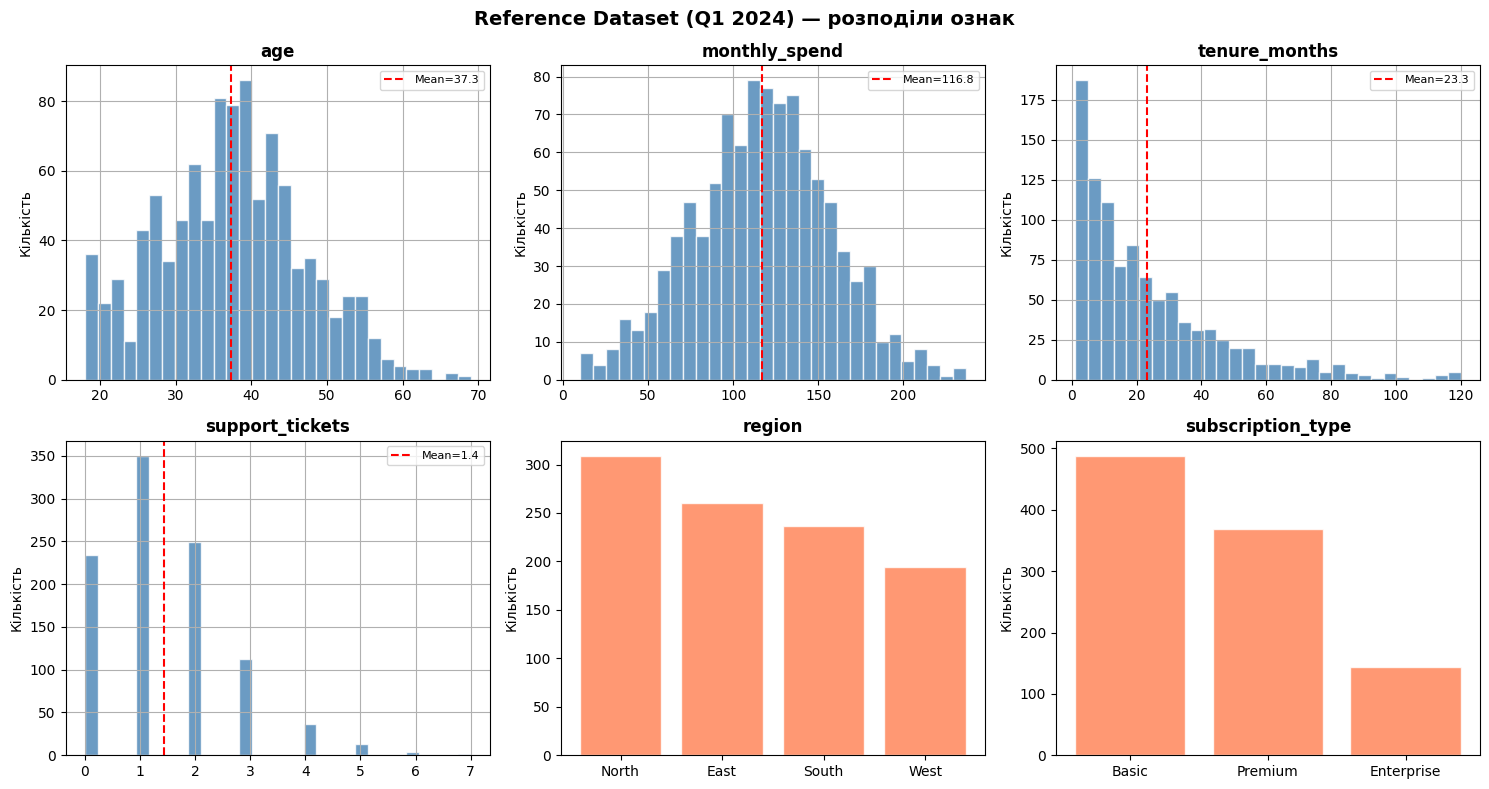

✅ Графік збережено: step1_reference_distributions.png


In [8]:
# ── 1в. Візуалізація reference-розподілів ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Reference Dataset (Q1 2024) — розподіли ознак', fontsize=14, fontweight='bold')

num_cols = ['age', 'monthly_spend', 'tenure_months', 'support_tickets']
cat_cols = ['region', 'subscription_type']

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    reference_df[col].hist(bins=30, color='steelblue', alpha=0.8, ax=ax, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Кількість')
    mean_val = reference_df[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean={mean_val:.1f}')
    ax.legend(fontsize=8)

for j, col in enumerate(cat_cols):
    ax = axes[1][j + 1]
    vc = reference_df[col].value_counts()
    ax.bar(vc.index, vc.values, color='coral', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Кількість')

plt.tight_layout()
plt.savefig('step1_reference_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Графік збережено: step1_reference_distributions.png")


---
## 🔍 Крок 2 — Валідація якості даних

### 🎓 Теорія: Категорії проблем якості даних

З **Лекції 6, Блок 1** — чотири категорії проблем якості:

| Категорія | Приклади | Небезпека |
|---|---|---|
| **Структурні** | Неправильний тип, відсутні обов'язкові поля | Крах пайплайну |
| **Статистичні** | Викиди, аномальні розподіли | Деградація моделі |
| **Семантичні** | Дублікати, суперечливі мітки | Data leakage, шум |
| **Часові** | Застарілі дані, порушення хронології | Temporal leakage |

> ⚠️ **Ключовий принцип:** Проблеми якості рідко видно через агреговані метрики моделі.  
> Їх потрібно шукати цілеспрямовано до того, як дані потраплять у модель.


In [9]:
# ── 2а. Введення штучних проблем якості для тренування ──────────────────────
# (Це імітує реальні помилки, які трапляються у production-потоках)

dirty_df = reference_df.copy()

# 1. Пропущені значення
idx_missing = np.random.choice(N_REF, size=30, replace=False)
dirty_df.loc[idx_missing[:15], 'monthly_spend'] = np.nan
dirty_df.loc[idx_missing[15:], 'age'] = np.nan

# 2. Викиди (outliers)
idx_outliers = np.random.choice(N_REF, size=10, replace=False)
dirty_df.loc[idx_outliers[:5], 'monthly_spend'] = np.random.uniform(2000, 9999, 5)  # аномально висока витрата
dirty_df.loc[idx_outliers[5:], 'support_tickets'] = np.random.randint(50, 100, 5)   # аномально багато тікетів

# 3. Точні дублікати
idx_dup = np.random.choice(N_REF, size=20, replace=False)
dirty_df = pd.concat([dirty_df, dirty_df.iloc[idx_dup]], ignore_index=True)

# 4. Некоректні типи/значення
idx_schema = np.random.choice(N_REF, size=8, replace=False)
dirty_df.loc[idx_schema[:4], 'age'] = -5          # від'ємний вік
dirty_df.loc[idx_schema[4:], 'region'] = 'UNKNOWN' # невалідне значення категорії

print("=== Датасет із штучними проблемами ===")
print(f"Розмір після дублювання: {dirty_df.shape[0]} рядків")
print()
print("Введені проблеми:")
print(f"  Пропущені значення (monthly_spend): {dirty_df['monthly_spend'].isna().sum()}")
print(f"  Пропущені значення (age):           {dirty_df['age'].isna().sum()}")
print(f"  Потенційні викиди (monthly_spend>500): {(dirty_df['monthly_spend'] > 500).sum()}")
print(f"  Потенційні викиди (support_tickets>20): {(dirty_df['support_tickets'] > 20).sum()}")
print(f"  Точні дублікати:                    {dirty_df.duplicated().sum()}")
print(f"  Від'ємний вік:                      {(dirty_df['age'] < 0).sum()}")
print(f"  Невалідне значення region:          {(dirty_df['region'] == 'UNKNOWN').sum()}")


=== Датасет із штучними проблемами ===
Розмір після дублювання: 1020 рядків

Введені проблеми:
  Пропущені значення (monthly_spend): 15
  Пропущені значення (age):           15
  Потенційні викиди (monthly_spend>500): 5
  Потенційні викиди (support_tickets>20): 5
  Точні дублікати:                    20
  Від'ємний вік:                      4
  Невалідне значення region:          4


In [10]:
# ── 2б. Валідація схеми ──────────────────────────────────────────────────────
print("=" * 60)
print("ВАЛІДАЦІЯ СХЕМИ")
print("=" * 60)

SCHEMA = {
    'age':               {'type': 'numeric', 'min': 0, 'max': 120, 'nullable': False},
    'monthly_spend':     {'type': 'numeric', 'min': 0, 'max': 1000, 'nullable': False},
    'tenure_months':     {'type': 'numeric', 'min': 0, 'max': 360, 'nullable': False},
    'support_tickets':   {'type': 'numeric', 'min': 0, 'max': 30,  'nullable': True},
    'region':            {'type': 'categorical', 'allowed': {'North','South','East','West'}, 'nullable': False},
    'subscription_type': {'type': 'categorical', 'allowed': {'Basic','Premium','Enterprise'}, 'nullable': False},
    'churn':             {'type': 'numeric', 'min': 0, 'max': 1, 'nullable': False},
}

schema_issues = []
for col, rules in SCHEMA.items():
    if col not in dirty_df.columns:
        schema_issues.append(f"  ❌ Відсутня колонка: {col}")
        continue

    # Nullable check
    null_count = dirty_df[col].isna().sum()
    if not rules.get('nullable', True) and null_count > 0:
        schema_issues.append(f"  ❌ {col}: {null_count} пропущених значень (NOT NULL)")

    # Range check
    if rules['type'] == 'numeric':
        filled = dirty_df[col].dropna()
        below = (filled < rules['min']).sum()
        above = (filled > rules['max']).sum()
        if below > 0:
            schema_issues.append(f"  ❌ {col}: {below} значень нижче мінімуму ({rules['min']})")
        if above > 0:
            schema_issues.append(f"  ❌ {col}: {above} значень вище максимуму ({rules['max']})")

    # Categorical check
    if rules['type'] == 'categorical':
        invalid = set(dirty_df[col].dropna().unique()) - rules['allowed']
        if invalid:
            cnt = dirty_df[col].isin(invalid).sum()
            schema_issues.append(f"  ❌ {col}: {cnt} невалідних значень: {invalid}")

if schema_issues:
    print(f"\n🔴 Знайдено {len(schema_issues)} порушень схеми:")
    for issue in schema_issues:
        print(issue)
else:
    print("\n✅ Схема валідна")

print()
print(f"Всього проблем: {len(schema_issues)}")


ВАЛІДАЦІЯ СХЕМИ

🔴 Знайдено 6 порушень схеми:
  ❌ age: 15 пропущених значень (NOT NULL)
  ❌ age: 4 значень нижче мінімуму (0)
  ❌ monthly_spend: 15 пропущених значень (NOT NULL)
  ❌ monthly_spend: 5 значень вище максимуму (1000)
  ❌ support_tickets: 5 значень вище максимуму (30)
  ❌ region: 4 невалідних значень: {'UNKNOWN'}

Всього проблем: 6


ВИЯВЛЕННЯ ВИКИДІВ

age:
  Z-score (|z|>3):   7 викидів
  IQR метод:        11 викидів
  Діапазон: [-5.0, 69.0]  |  Mean: 37.2  |  Std: 10.0

monthly_spend:
  Z-score (|z|>3):   5 викидів
  IQR метод:        14 викидів
  Діапазон: [10.0, 8253.5]  |  Mean: 147.8  |  Std: 442.5

tenure_months:
  Z-score (|z|>3):  18 викидів
  IQR метод:        47 викидів
  Діапазон: [1.0, 120.0]  |  Mean: 23.2  |  Std: 22.7

support_tickets:
  Z-score (|z|>3):   5 викидів
  IQR метод:        61 викидів
  Діапазон: [0.0, 96.0]  |  Mean: 1.8  |  Std: 5.5


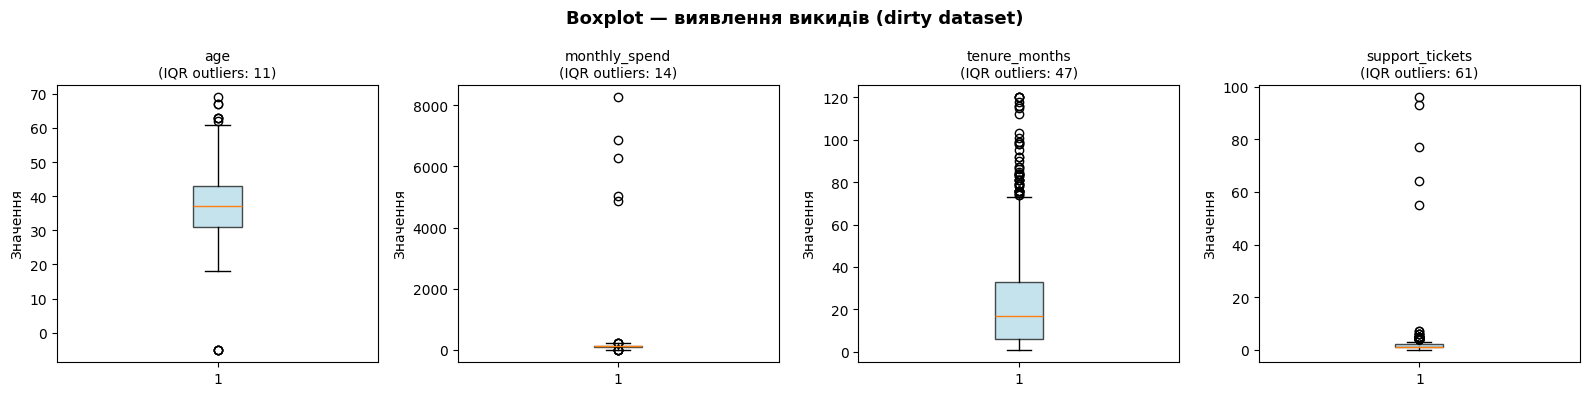

In [11]:
# ── 2в. Виявлення викидів — Z-score та IQR ───────────────────────────────────
print("=" * 60)
print("ВИЯВЛЕННЯ ВИКИДІВ")
print("=" * 60)

numeric_cols = ['age', 'monthly_spend', 'tenure_months', 'support_tickets']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
fig.suptitle('Boxplot — виявлення викидів (dirty dataset)', fontsize=13, fontweight='bold')

for i, col in enumerate(numeric_cols):
    col_data = dirty_df[col].dropna()

    # Z-score метод
    z_scores = np.abs(stats.zscore(col_data))
    n_zscore = (z_scores > 3).sum()

    # IQR метод
    Q1, Q3 = col_data.quantile(0.25), col_data.quantile(0.75)
    IQR = Q3 - Q1
    n_iqr = ((col_data < Q1 - 1.5*IQR) | (col_data > Q3 + 1.5*IQR)).sum()

    print(f"\n{col}:")
    print(f"  Z-score (|z|>3): {n_zscore:3d} викидів")
    print(f"  IQR метод:       {n_iqr:3d} викидів")
    print(f"  Діапазон: [{col_data.min():.1f}, {col_data.max():.1f}]  |  Mean: {col_data.mean():.1f}  |  Std: {col_data.std():.1f}")

    axes[i].boxplot(col_data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[i].set_title(f'{col}\n(IQR outliers: {n_iqr})', fontsize=10)
    axes[i].set_ylabel('Значення')

plt.tight_layout()
plt.savefig('step2_outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# ── 2г. Дублікати та пропущені значення ──────────────────────────────────────
print("=" * 60)
print("ДУБЛІКАТИ")
print("=" * 60)
n_exact_dup = dirty_df.duplicated().sum()
print(f"Точних дублікатів: {n_exact_dup} з {len(dirty_df)} рядків ({n_exact_dup/len(dirty_df):.1%})")
print()

print("=" * 60)
print("ПРОПУЩЕНІ ЗНАЧЕННЯ")
print("=" * 60)
missing = dirty_df.isnull().sum()
missing_pct = (missing / len(dirty_df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent(%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
if missing_df.empty:
    print("✅ Пропущених значень немає")
else:
    print(missing_df.to_string())

print()
print("=" * 60)
print("РЕЗЮМЕ ЯКОСТІ ДАНИХ")
print("=" * 60)
total_issues = n_exact_dup + missing['monthly_spend'] + missing['age']
print(f"  Всього рядків:          {len(dirty_df)}")
print(f"  Точні дублікати:        {n_exact_dup}")
print(f"  Рядки з пропусками:     {dirty_df.isnull().any(axis=1).sum()}")
print(f"  Порушення схеми:        {len(schema_issues)}")
print(f"  Загальна оцінка якості: {'🔴 НИЗЬКА' if total_issues > 20 else '🟡 СЕРЕДНЯ' if total_issues > 5 else '🟢 ВИСОКА'}")


ДУБЛІКАТИ
Точних дублікатів: 20 з 1020 рядків (2.0%)

ПРОПУЩЕНІ ЗНАЧЕННЯ
               Count  Percent(%)
age               15        1.47
monthly_spend     15        1.47

РЕЗЮМЕ ЯКОСТІ ДАНИХ
  Всього рядків:          1020
  Точні дублікати:        20
  Рядки з пропусками:     30
  Порушення схеми:        6
  Загальна оцінка якості: 🔴 НИЗЬКА


### 📝 Завдання 1 — Валідація якості даних

**1.1.** Заповніть таблицю знайдених проблем:

| Тип проблеми | Колонка | Кількість | Категорія (з лекції) |
|---|---|---|---|
| Пропущені значення | monthly_spend | 15 | статистична |
| Пропущені значення | age | 15  | статистична |
| Точні дублікати | — | 20 | структурна |
| Викиди (IQR) | monthly_spend | 14 | статистична |
| 14екоректний діапазон | age | 4| семантична |
| Невалідне значення | region | 4 | семантична |

---

**1.2.** Якою є категорія за механізмом пропуску значень у колонці `monthly_spend`?  
Вибрати: **MCAR / MAR / MNAR**. Обґрунтуйте відповідь (2-3 речення).

> **Ваша відповідь:**  
> *(Пропуски у monthly_spend класифікуються як MAR тому що їх поява залежить від інших спостережуваних змінних. В даному випадку від subscription_type та region)*

---

**1.3.** Чому near-duplicates небезпечніші за точні дублікати в контексті train/test розбиття?

> **Ваша відповідь** *(2-3 речення, використайте термін data leakage)*:  
> *(Точні дублікати можна виявити стандартними інструментами наприклад .duplicated() і видалити автоматично. Near-duplicates це рядки даних з мінімальними відмінностями. Наприклад, age = 51 та age = 52 при тому, що інші поля однакові. Тому алгоритми не виявляють як дублікати і вони потрапляють одночасно в трейн і тест вибірки. Це призводить до data leakage)*


---
## 🌊 Крок 3 — Симуляція сценаріїв дрейфу

### 🎓 Теорія: Три типи дрейфу

З **Лекції 6, Блок 2** — дрейф неминучий, бо реальний світ змінюється:

| Тип дрейфу | Що змінюється | Приклад |
|---|---|---|
| **Data drift** | P(X) — розподіл входів | Нова аудиторія молодших клієнтів |
| **Concept drift** | P(Y\|X) — зв'язок вхід→вихід | Нове значення ознаки після події |
| **Label drift** | P(Y) — розподіл цілі | Зростання churn-rate через кризу |

> ⚠️ **Різні типи дрейфу → різні реакції:**  
> Data drift → перетренувати на нових даних  
> Concept drift → переглянути feature engineering або архітектуру  
> Label drift → перекалібрувати пороги прийняття рішень


In [13]:
# ── 3а. Генерація current-датасету (Q4 2024) із drift ────────────────────────
N_CURR = 800

def generate_current_data_with_drift(n, seed=99):
    rng = np.random.default_rng(seed)

    # === DATA DRIFT: вікова аудиторія змолодшала (рекламна кампанія) ===
    # Reference: mean=38, std=10 → Current: mean=28, std=8
    age = rng.normal(28, 8, n).clip(18, 75).astype(int)

    # === DATA DRIFT: monthly_spend зменшився (економічна ситуація) ===
    # Reference: mean=120 → Current: mean=85
    monthly_spend = rng.normal(85, 35, n).clip(10, 500).round(2)

    tenure_months = rng.exponential(18, n).clip(1, 120).astype(int)

    # === DATA DRIFT: більше звернень у підтримку ===
    support_tickets = rng.poisson(2.8, n)  # Reference: 1.5

    # === LABEL DRIFT: частка churn зросла ===
    # Reference: ~20% churn → Current: ~35% churn
    region   = rng.choice(['North','South','East','West'], n, p=[0.3,0.25,0.25,0.2])
    sub_type = rng.choice(['Basic','Premium','Enterprise'], n, p=[0.60,0.30,0.10])  # більше Basic

    # === CONCEPT DRIFT: змінився зв'язок tenure → churn ===
    # Раніше нові клієнти частіше йшли, тепер навпаки — стабільні клієнти теж йдуть
    churn_prob = (
        0.15                                     # базова ставка вища
        + 0.10 * (monthly_spend < 80)            # низька витрата → churn
        + 0.18 * (support_tickets >= 3)          # більший вплив tickets
        + 0.12 * (tenure_months > 24)            # ЗМІНА: стабільні клієнти теж йдуть!
        - 0.05 * (sub_type == 'Enterprise')
    )
    churn = (rng.uniform(0, 1, n) < churn_prob).astype(int)

    return pd.DataFrame({
        'age': age, 'monthly_spend': monthly_spend,
        'tenure_months': tenure_months, 'support_tickets': support_tickets,
        'region': region, 'subscription_type': sub_type, 'churn': churn
    })

current_df = generate_current_data_with_drift(N_CURR)

print("=== Current Dataset (Q4 2024) ===")
print(f"Розмір: {current_df.shape}")
print(f"\nРозподіл churn:")
churn_curr = current_df['churn'].value_counts()
print(f"  Залишились (0): {churn_curr[0]:4d}  ({churn_curr[0]/N_CURR:.1%})")
print(f"  Відтік    (1): {churn_curr.get(1,0):4d}  ({churn_curr.get(1,0)/N_CURR:.1%})")


=== Current Dataset (Q4 2024) ===
Розмір: (800, 7)

Розподіл churn:
  Залишились (0):  526  (65.8%)
  Відтік    (1):  274  (34.2%)


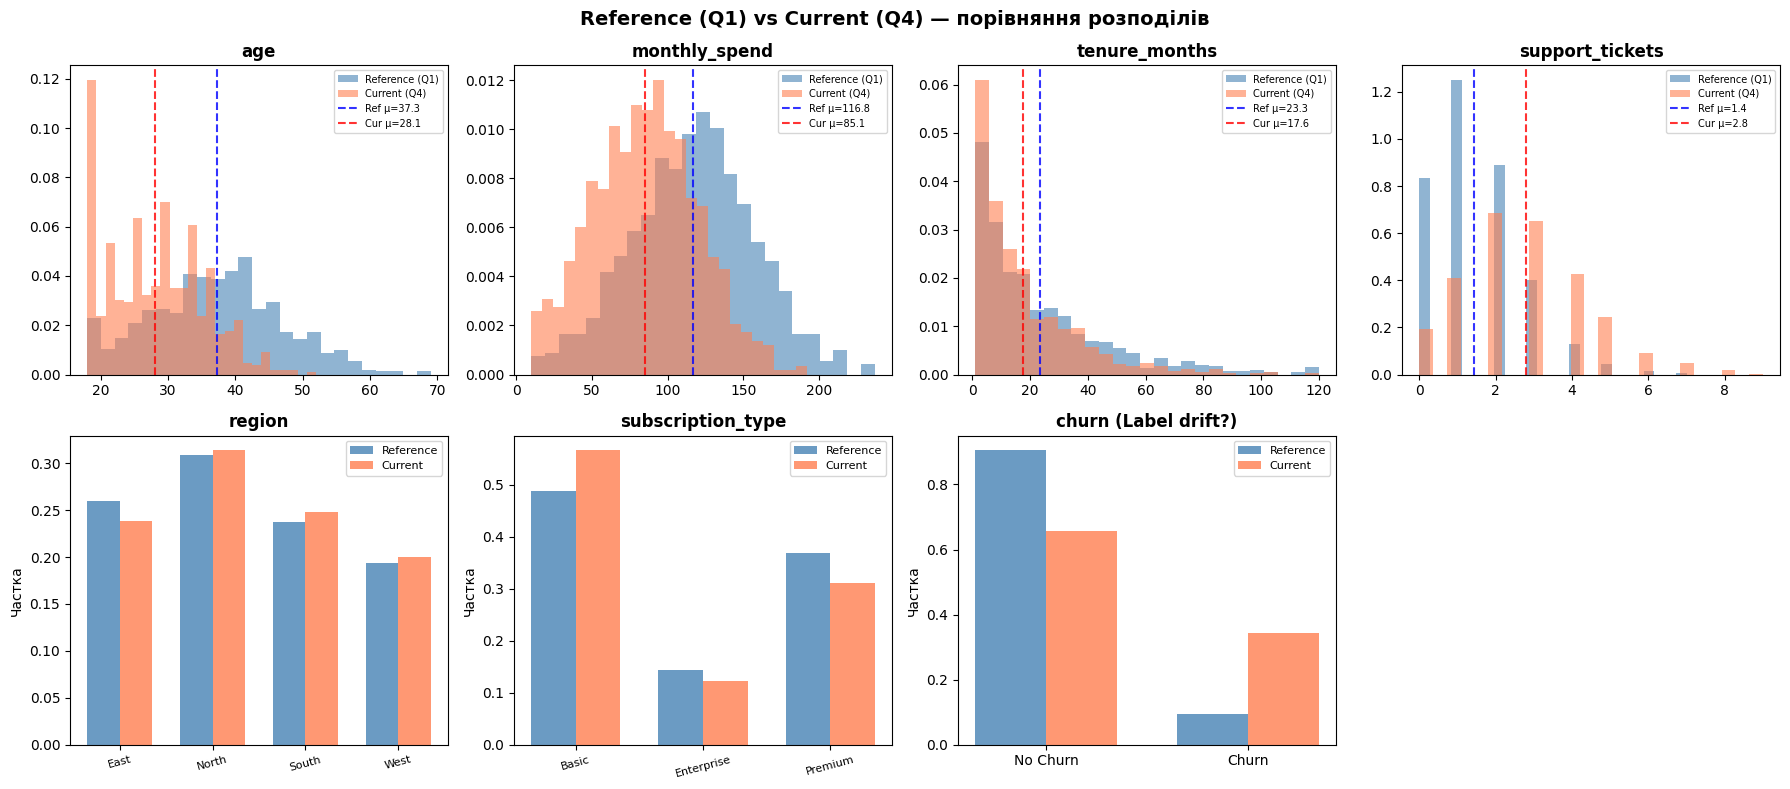

✅ Графік збережено: step3_drift_comparison.png


In [14]:
# ── 3б. Порівняння розподілів Reference vs Current ───────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Reference (Q1) vs Current (Q4) — порівняння розподілів', fontsize=14, fontweight='bold')

num_cols = ['age', 'monthly_spend', 'tenure_months', 'support_tickets']
cat_cols = ['region', 'subscription_type']

for i, col in enumerate(num_cols):
    ax = axes[0][i]
    ref_vals = reference_df[col].dropna()
    cur_vals = current_df[col].dropna()
    ax.hist(ref_vals, bins=25, alpha=0.6, color='steelblue', label='Reference (Q1)', density=True)
    ax.hist(cur_vals, bins=25, alpha=0.6, color='coral',     label='Current (Q4)',   density=True)
    ax.axvline(ref_vals.mean(), color='blue',   linestyle='--', alpha=0.8, label=f'Ref μ={ref_vals.mean():.1f}')
    ax.axvline(cur_vals.mean(), color='red',    linestyle='--', alpha=0.8, label=f'Cur μ={cur_vals.mean():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)

for j, col in enumerate(cat_cols):
    ax = axes[1][j]
    ref_pct = reference_df[col].value_counts(normalize=True).sort_index()
    cur_pct = current_df[col].value_counts(normalize=True).sort_index()
    all_cats = sorted(set(ref_pct.index) | set(cur_pct.index))
    x = np.arange(len(all_cats)); w = 0.35
    ax.bar(x - w/2, [ref_pct.get(c,0) for c in all_cats], w, label='Reference', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, [cur_pct.get(c,0) for c in all_cats], w, label='Current',   color='coral',    alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(all_cats, rotation=15, fontsize=8)
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=8)
    ax.set_ylabel('Частка')

# churn comparison
ax_churn = axes[1][2]
ref_churn = reference_df['churn'].value_counts(normalize=True).sort_index()
cur_churn = current_df['churn'].value_counts(normalize=True).sort_index()
x = np.arange(2); w = 0.35
ax_churn.bar(x - w/2, [ref_churn.get(0,0), ref_churn.get(1,0)], w, label='Reference', color='steelblue', alpha=0.8)
ax_churn.bar(x + w/2, [cur_churn.get(0,0), cur_churn.get(1,0)], w, label='Current',   color='coral',    alpha=0.8)
ax_churn.set_xticks(x); ax_churn.set_xticklabels(['No Churn','Churn'])
ax_churn.set_title('churn (Label drift?)', fontweight='bold'); ax_churn.legend(fontsize=8)
ax_churn.set_ylabel('Частка')

axes[1][3].axis('off')
plt.tight_layout()
plt.savefig('step3_drift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Графік збережено: step3_drift_comparison.png")


### 📝 Завдання 2 — Визначення типів дрейфу

Розгляньте графіки та заповніть таблицю:

| Ознака | Зміна (Reference → Current) | Тип дрейфу | Ступінь (Low/Medium/High) |
|---|---|---|---|
| `age` | Mean 38 → 28 | Data drift | High |
| `monthly_spend` | Mean 120 → 85 | Data drift | High |
| `support_tickets` | Poisson λ=1.5 → 2.8 | Data drift | Medium |
| `churn` (rate) | ~20% → ~35% | Label drift | High |
| `tenure` → `churn` зв'язок | Нові клієнти йшли → старі теж йдуть | Concept drift | Medium |

---

**2.1.** Яку реакцію команди вимагає кожен виявлений тип дрейфу?  
*(Використайте класифікацію з Лекції 6: перетренувати / переглянути feature engineering / перекалібрувати пороги)*

> **Ваша відповідь:**  
> *(Для Data drift  необхідно перетренувати модель на нових даних, в нашому випадку таких що включають молодшу аудиторію з нижчими витратами. Тому що ми бачимо що розподіл вхідних ознак P(X) сильно змінився, значить модель отримує дані, яких не бачила під час навчання.  Для Label drift потрібно перекалібрувати пороги прийняття рішень, можна обійтись без без перетренування asap. Ми бачимо що розподіл цільової змінної P(Y) різко зріс, значить модель навчена на 10% churn недооцінює ризик відтоку. Для Concept drift потрібен перегляд feature engineering. Видно що змінився розподіл P(Y|X) тому треба спробувати додати нові ознаки, щось типу "активність за останній місяць" )*


---
## 📈 Крок 4 — Evidently AI: Drift Report

### 🎓 Теорія: Evidently AI (Лекція 6, Блок 4)

Evidently спеціалізується на **моніторингу моделей у продакшені**.
Ключова концепція: **reference vs current** — порівняння еталонного і поточного розподілів.

#### Два рівні використання

| Рівень | Клас | Коли використовувати |
|---|---|---|
| **Presets** | `DataDriftPreset`, `DataQualityPreset` | Швидкий старт, огляд |
| **Individual metrics** | `ColumnDriftMetric`, `ColumnSummaryMetric` | Точне налаштування, різні тести |

#### ColumnMapping — обов'язковий крок

```python
column_mapping = ColumnMapping(
    target='churn',
    numerical_features=['age', 'monthly_spend', 'tenure_months', 'support_tickets'],
    categorical_features=['region', 'subscription_type']
)
```
Без `ColumnMapping` Evidently інферує типи і може обрати неправильний статистичний тест.

#### Доступні stattest для `ColumnDriftMetric`

| `stattest=` | Тип даних | Що вимірює |
|---|---|---|
| `'ks'` | Числові | KS-статистика, p-value |
| `'psi'` | Числові/категоріальні | PSI індекс |
| `'chisquare'` | Категоріальні | Chi-squared, p-value |
| `'wasserstein'` | Числові | Earth Mover's Distance |
| `'kl_div'` | Числові | KL-дивергенція |


In [15]:
# ── 4а. ColumnMapping + DataDriftPreset з явним вибором статистичних тестів ──

# КРОК 1: Оголошуємо ColumnMapping — Evidently знає точно, яка колонка що таке
column_mapping = ColumnMapping(
    target='churn',
    numerical_features=['age', 'monthly_spend', 'tenure_months', 'support_tickets'],
    categorical_features=['region', 'subscription_type']
)

# КРОК 2: DataDriftPreset з явним вибором тестів і порогів
#   num_stattest  — тест для числових ознак (ks, psi, wasserstein, kl_div)
#   cat_stattest  — тест для категоріальних (chi2, psi, jensenshannon)
#   *_threshold   — p-value або PSI, при якому рахується дрейф
report = Report(metrics=[
    DataDriftPreset(
        num_stattest='ks',
        cat_stattest='chisquare',
        num_stattest_threshold=0.05,
        cat_stattest_threshold=0.05,
    ),
    DataQualityPreset(),
])

report.run(
    reference_data=reference_df,
    current_data=current_df,
    column_mapping=column_mapping,
)
report.save_html('evidently_drift_report.html')
print('✅ Звіт збережено: evidently_drift_report.html')

# КРОК 3: Читаємо результати через as_dict()
report_dict = report.as_dict()

print()
print('=== SUMMARY: DataDrift ===')
for metric in report_dict.get('metrics', []):
    result = metric.get('result', {})
    if 'number_of_drifted_columns' in result:
        n_drifted = result['number_of_drifted_columns']
        n_total   = result['number_of_columns']
        share     = result['share_of_drifted_columns']
        drifted   = result['dataset_drift']
        print(f"  Дрейф виявлено:    {'🔴 ТАК' if drifted else '🟢 НІ'}")
        print(f"  Колонок з дрейфом: {n_drifted} з {n_total} ({share:.0%})")
        break

print()
print(f"{'Колонка':<22} {'Тест':<12} {'Статистика':>12} {'p-value':>10}  {'Дрейф?'}")
print('─' * 70)
for metric in report_dict.get('metrics', []):
    result = metric.get('result', {})
    if 'column_name' in result and 'drift_detected' in result:
        col   = result['column_name']
        test  = result.get('stattest_name', '?')
        stat  = result.get('drift_score', result.get('statistic', float('nan')))
        pval  = result.get('p_value', float('nan'))
        drift = result['drift_detected']
        icon  = '🔴 ТАК' if drift else '🟢 НІ'
        s_str = f'{stat:.4f}' if isinstance(stat, float) else str(stat)
        p_str = f'{pval:.4f}' if isinstance(pval, float) else '—'
        print(f"  {col:<20} {test:<12} {s_str:>12} {p_str:>10}  {icon}")


✅ Звіт збережено: evidently_drift_report.html

=== SUMMARY: DataDrift ===
  Дрейф виявлено:    🔴 ТАК
  Колонок з дрейфом: 6 з 7 (86%)

Колонка                Тест           Статистика    p-value  Дрейф?
──────────────────────────────────────────────────────────────────────


In [16]:
# ── 4г. ColumnDriftMetric — PSI для кожної колонки окремо ──────────────────
# На відміну від preset, тут ми обираємо КОНКРЕТНИЙ тест для кожної колонки.
# Це головна перевага individual metrics над presets.

psi_report = Report(metrics=[
    ColumnDriftMetric(column_name='age',              stattest='psi'),
    ColumnDriftMetric(column_name='monthly_spend',    stattest='psi'),
    ColumnDriftMetric(column_name='tenure_months',    stattest='psi'),
    ColumnDriftMetric(column_name='support_tickets',  stattest='psi'),
    ColumnDriftMetric(column_name='region',           stattest='psi'),
    ColumnDriftMetric(column_name='subscription_type',stattest='psi'),
])
psi_report.run(
    reference_data=reference_df,
    current_data=current_df,
    column_mapping=column_mapping,
)

def psi_label(v):
    return '🟢 Без дрейфу' if v < 0.1 else ('🟡 Помірний' if v < 0.25 else '🔴 Значний')

psi_results_evidently = {}
print('=== PSI через ColumnDriftMetric (Evidently) ===')
print(f"{'Ознака':<24} {'PSI':>8}  {'Статус'}")
print('─' * 55)
for metric in psi_report.as_dict().get('metrics', []):
    result = metric.get('result', {})
    if 'column_name' in result and 'drift_detected' in result:
        col  = result['column_name']
        psi  = result.get('drift_score', result.get('statistic', float('nan')))
        psi_results_evidently[col] = psi
        print(f"  {col:<22} {psi:>8.4f}  {psi_label(psi)}")


=== PSI через ColumnDriftMetric (Evidently) ===
Ознака                        PSI  Статус
───────────────────────────────────────────────────────
  age                      1.2897  🔴 Значний
  monthly_spend            0.7524  🔴 Значний
  tenure_months            0.0926  🟢 Без дрейфу
  support_tickets          0.9052  🔴 Значний
  region                   0.0025  🟢 Без дрейфу
  subscription_type        0.0246  🟢 Без дрейфу


In [17]:
# ── 4д. Порівняння статистичних тестів для однієї ознаки ────────────────────
# Evidently дозволяє запустити різні тести для ТІЄЇ САМОЇ колонки
# і порівняти — чи вони погоджуються у висновку про дрейф?

STATTESTS = ['ks', 'psi', 'wasserstein', 'kl_div']
TARGET_COL = 'monthly_spend'   # колонка з очевидним дрейфом (mean 120→85)

multi_report = Report(metrics=[
    ColumnDriftMetric(column_name=TARGET_COL, stattest=st)
    for st in STATTESTS
])
multi_report.run(
    reference_data=reference_df,
    current_data=current_df,
    column_mapping=column_mapping,
)

print(f"=== Порівняння тестів для '{TARGET_COL}' ===")
print(f"  Reference mean: {reference_df[TARGET_COL].mean():.1f}")
print(f"  Current   mean: {current_df[TARGET_COL].mean():.1f}")
print()
print(f"{'Тест':<14} {'Значення':>12} {'p-value':>10} {'Дрейф?'}")
print('─' * 50)
for metric in multi_report.as_dict().get('metrics', []):
    result = metric.get('result', {})
    if 'column_name' not in result:
        continue
    test = result.get('stattest_name', '?')
    stat = result.get('drift_score', result.get('statistic', float('nan')))
    pval = result.get('p_value', float('nan'))
    drift = result.get('drift_detected', False)
    icon  = '🔴 ТАК' if drift else '🟢 НІ'
    p_str = f'{pval:.4f}' if isinstance(pval, float) and not np.isnan(pval) else '—'
    print(f"  {test:<12} {stat:>12.4f} {p_str:>10}  {icon}")

print()
print('💡 Wasserstein і KL-div не мають p-value — вони є відстанями, не тестами.')
print('   Їх порівнюють з вручну встановленим порогом, а не з α=0.05.')


=== Порівняння тестів для 'monthly_spend' ===
  Reference mean: 116.8
  Current   mean: 85.1

Тест               Значення    p-value Дрейф?
──────────────────────────────────────────────────
  K-S p_value        0.0000          —  🔴 ТАК
  PSI                0.7524          —  🔴 ТАК
  Wasserstein distance (normed)       0.7815          —  🔴 ТАК
  Kullback-Leibler divergence       0.4332          —  🔴 ТАК

💡 Wasserstein і KL-div не мають p-value — вони є відстанями, не тестами.
   Їх порівнюють з вручну встановленим порогом, а не з α=0.05.


In [18]:
# ── 4б. Evidently Target Drift Report ───────────────────────────────────────
# TargetDriftPreset аналізує churn (target) + передбачення моделі.
# ColumnMapping(target=...) є ОБОВ'ЯЗКОВИМ — без нього Evidently не знає, що є ціллю.

target_report = Report(metrics=[TargetDriftPreset()])
target_report.run(
    reference_data=reference_df,
    current_data=current_df,
    column_mapping=column_mapping,   # використовуємо вже оголошений вище
)
target_report.save_html('evidently_target_drift_report.html')
print('✅ Target drift звіт збережено: evidently_target_drift_report.html')

# Читаємо результати з target_report (не з report_dict!)
target_report_dict = target_report.as_dict()

print()
print('=== Target Drift Results ===')
print(f"{'Колонка':<22} {'Тест':<12} {'Значення':>10} {'p-value':>10}  {'Дрейф?'}")
print('─' * 65)
for metric in target_report_dict.get('metrics', []):
    result = metric.get('result', {})
    if 'column_name' in result and 'drift_detected' in result:
        col   = result['column_name']
        test  = result.get('stattest_name', '?')
        stat  = result.get('drift_score', result.get('statistic', float('nan')))
        pval  = result.get('p_value', float('nan'))
        drift = result['drift_detected']
        icon  = '🔴 ТАК' if drift else '🟢 НІ'
        s_str = f'{stat:.4f}' if isinstance(stat, float) else str(stat)
        p_str = f'{pval:.4f}' if isinstance(pval, float) else '—'
        print(f"  {col:<20} {test:<12} {s_str:>10} {p_str:>10}  {icon}")


✅ Target drift звіт збережено: evidently_target_drift_report.html

=== Target Drift Results ===
Колонка                Тест           Значення    p-value  Дрейф?
─────────────────────────────────────────────────────────────────
  churn                Z-test p_value     0.0000        nan  🔴 ТАК


In [19]:
# ── 4в. Evidently TestSuite — CI/CD gate з кастомними умовами ───────────────
# TestSuite дозволяє задати ЯВНІ умови проходження/провалу.
# Це ключова перевага для інтеграції в CI/CD: не просто звіт, а pass/fail gate.

suite = TestSuite(tests=[
    # Presets — стандартні перевірки якості і дрейфу
    DataDriftTestPreset(),
    DataQualityTestPreset(),

    # Кастомний поріг: ПРОВАЛ якщо >30% колонок дрейфують
    TestShareOfDriftedColumns(lt=0.3),

    # Per-column тести з явним статистичним тестом
    # Evidently провалить gate якщо БУДЬ-ЯКА з цих колонок дрейфує
    TestColumnDrift(column_name='age',             stattest='ks'),
    TestColumnDrift(column_name='monthly_spend',   stattest='ks'),
    TestColumnDrift(column_name='tenure_months',   stattest='ks'),
    TestColumnDrift(column_name='support_tickets', stattest='ks'),
    TestColumnDrift(column_name='region',          stattest='chisquare'),
    TestColumnDrift(column_name='subscription_type', stattest='chisquare'),
])

suite.run(
    reference_data=reference_df,
    current_data=current_df,
    column_mapping=column_mapping,
)

results_dict = suite.as_dict()
summary = results_dict.get('summary', {})

print('=== TestSuite Results (CI/CD-стиль) ===')
print(f"  Всього тестів:  {summary.get('total_tests', '?')}")
print(f"  Пройдено:       {summary.get('success_tests', '?')} ✅")
print(f"  Провалено:      {summary.get('failed_tests', '?')} ❌")
print(f"  Попередження:   {summary.get('warning_tests', '?')} ⚠️")
print()

# Per-test деталі
print(f"{'Тест':<45} {'Результат'}")
print('─' * 60)
for test in results_dict.get('tests', []):
    name   = test.get('name', '?')
    status = test.get('status', '?')
    desc   = test.get('description', '')
    icon   = '✅' if status == 'SUCCESS' else ('❌' if status == 'FAIL' else '⚠️')
    print(f"  {name:<43} {icon} {status}")
    if status == 'FAIL':
        print(f"    ↳ {desc}")

print()
all_passed = summary.get('all_passed', True)
print(f"CI/CD Gate: {'✅ PASSED — безпечно деплоїти' if all_passed else '❌ FAILED — деплой заблоковано!'}")
print()
print('# Код для pytest/CI:')
print("# assert suite.as_dict()['summary']['all_passed'], 'Data drift detected — blocked!'")


=== TestSuite Results (CI/CD-стиль) ===
  Всього тестів:  31
  Пройдено:       13 ✅
  Провалено:      18 ❌
  Попередження:   ? ⚠️

Тест                                          Результат
────────────────────────────────────────────────────────────
  Share of Drifted Columns                    ❌ FAIL
    ↳ The drift is detected for 85.7% features (6 out of 7). The test threshold is lt=0.3
  Drift per Column                            ❌ FAIL
    ↳ The drift score for the feature **age** is 0. The drift detection method is K-S p_value. The drift detection threshold is 0.05.
  Drift per Column                            ❌ FAIL
    ↳ The drift score for the feature **monthly_spend** is 0. The drift detection method is K-S p_value. The drift detection threshold is 0.05.
  Drift per Column                            ❌ FAIL
    ↳ The drift score for the feature **tenure_months** is 0. The drift detection method is K-S p_value. The drift detection threshold is 0.05.
  Drift per Column          

### 📝 Завдання 3 — Evidently AI аналіз

**3.1.** Скільки колонок отримали дрейф за `DataDriftPreset` (KS/chi2 тести)?  
Які саме? Порівняйте з результатами `ColumnDriftMetric(stattest='psi')` — чи є розбіжності?

> **Ваша відповідь:**  
> *(KS/chi2: 6 колонок; PSI: 3 колоноки; розбіжності: KS/chi2 виявляє дрейф, PSI - ні. Так стається тому що KS чутливий до будь-якої зміни форми розподілу)*

---

**3.2.** У клітинці 4д порівнюються 4 тести для `monthly_spend`.  
Чому KS і PSI дають однаковий висновок (дрейф), але різні числові значення?  
У чому різниця між тестом з p-value і метрикою відстані (Wasserstein)?

> **Ваша відповідь** *(2-3 речення)*:  
> *(KS вимірює максимальну різницю між комулятивними розподілами і повертає p-value. PSI вимірює відносну різницю між гістограмами по бінах і повертає індекс. Обидва показують що дрейф є, але відповідають на різні питання: KS — "чи значима різниця статистично", PSI - "наскільки змінився розподіл кількісно". Wasserstein на відміну від KS не має p-value — це метрика відстані між розподілами, яку порівнюють з вручну встановленим порогом)*

---

**3.3.** У `TestSuite` (клітинка 4в) які тести провалились?  
Чим відрізняється `TestShareOfDriftedColumns(lt=0.3)` від `TestColumnDrift(column_name='age')`?  
Який із них важливіший для CI/CD блокування деплою — і чому?

> **Ваша відповідь:**  
> *(провалились 18 з 31 -  8 drift тестів, 6 тестів Share of Most Common Value.
TestShareOfDriftedColumns(lt=0.3) — датасет-рівень: перевіряє чи частка задрейфованих колонок менша за 30%. Результат: 85.7% > 30% → fail. TestColumnDrift(column_name='age') — колонка-рівень: перевіряє конкретно age, p-value=0.000 → fail.
Для CI/CD важливіший TestShareOfDriftedColumns — він дає єдиний pass/fail сигнал для всього датасету і не потребує перерахування кожної колонки окремо
)*

---

**3.4.** Відкрийте `evidently_drift_report.html` у браузері.  
Яка ознака показала найбільший дрейф? Порівняйте візуалізацію Evidently
з matplotlib-гістограмою зі Step 3б — яка зрозуміліша і чому?

> **Ваша відповідь:**  
> *(Найбільший дрейф показала ознака age (PSI = 1.29 — найвище значення). Evidently HTML-звіт зручніший за matplotlib-гістограму: він інтерактивний, показує обидва розподіли накладено, підсвічує статистику і threshold прямо на графіку. Matplotlib-гістограма зі Step 3б потребує ручної інтерпретації, але краща для швидкого порівняння середніх)*


---
## 🔬 Крок 5 — Валідація результатів Evidently вручну

### 🎓 Теорія: Чому варто розуміти математику за Evidently

У Кроці 4 ми використали `ColumnDriftMetric(stattest='psi')` — Evidently сам обрахував PSI.  
У цьому кроці ми **відтворимо PSI вручну через numpy** і порівняємо результати.  
Мета — переконатись, що Evidently робить те, що очікується, і навчитись **читати числа**.

| Метрика | Тип даних | Інтерпретація |
|---|---|---|
| **PSI** (Population Stability Index) | Числові, категоріальні | < 0.1 = норма, 0.1–0.25 = помірний, > 0.25 = значний |
| **KS-test** | Числові | p < 0.05 → розподіли статистично різні |
| **Chi-squared** | Категоріальні | p < 0.05 → розподіл категорій змінився |
| **Wasserstein** | Числові | «Earth Mover's Distance» — перевіряємо через scipy vs Evidently |


In [20]:
# ── 5а. PSI: Evidently vs ручний розрахунок numpy ──────────────────────────
# Evidently вже порахував PSI у клітинці 4г (psi_results_evidently).
# Тепер відтворимо вручну і порівняємо — розбіжності мають бути мінімальними.

def calculate_psi_manual(reference, current, bins=10):
    """Ручний PSI через numpy — для порівняння з Evidently."""
    min_val = min(reference.min(), current.min())
    max_val = max(reference.max(), current.max())
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    ref_counts, _ = np.histogram(reference, bins=bin_edges)
    cur_counts, _ = np.histogram(current,   bins=bin_edges)
    ref_pct = np.where(ref_counts == 0, 0.001, ref_counts / len(reference))
    cur_pct = np.where(cur_counts == 0, 0.001, cur_counts / len(current))
    return np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))

def psi_label(v):
    return '🟢 Без дрейфу' if v < 0.1 else ('🟡 Помірний' if v < 0.25 else '🔴 Значний')

num_cols = ['age', 'monthly_spend', 'tenure_months', 'support_tickets']

print('=' * 72)
print('PSI — порівняння: Evidently vs ручний розрахунок numpy')
print('=' * 72)
print(f"{'Ознака':<22} {'Evidently PSI':>14} {'Manual PSI':>12} {'Δ':>8}  {'Статус'}")
print('─' * 72)

psi_results = {}
for col in num_cols:
    ref = reference_df[col].dropna().values
    cur = current_df[col].dropna().values
    manual_psi   = calculate_psi_manual(ref, cur)
    evidently_psi = psi_results_evidently.get(col, float('nan'))
    delta = abs(manual_psi - evidently_psi)
    psi_results[col] = evidently_psi   # використовуємо Evidently як джерело істини
    print(f"  {col:<20} {evidently_psi:>14.4f} {manual_psi:>12.4f} {delta:>8.4f}  {psi_label(evidently_psi)}")

print()
print('💡 Невелика різниця (Δ) виникає через різну кількість bins.')
print('   Evidently використовує власну евристику для вибору bins — зазвичай точніше.')


PSI — порівняння: Evidently vs ручний розрахунок numpy
Ознака                  Evidently PSI   Manual PSI        Δ  Статус
────────────────────────────────────────────────────────────────────────
  age                          1.2897       1.2003   0.0894  🔴 Значний
  monthly_spend                0.7524       0.7322   0.0201  🔴 Значний
  tenure_months                0.0926       0.0823   0.0103  🟢 Без дрейфу
  support_tickets              0.9052       0.8835   0.0217  🔴 Значний

💡 Невелика різниця (Δ) виникає через різну кількість bins.
   Evidently використовує власну евристику для вибору bins — зазвичай точніше.


In [21]:
# ── 5б. KS-test, Chi-squared та Wasserstein — scipy vs Evidently ────────────
print('=' * 65)
print('Kolmogorov-Smirnov Test (числові ознаки)')
print('H₀: обидва розподіли з однієї генеральної сукупності')
print('=' * 65)
print(f"{'Ознака':<22} {'KS-статистика':>15} {'p-value':>12}  {'Висновок'}")
print('─' * 65)
for col in ['age', 'monthly_spend', 'tenure_months', 'support_tickets']:
    ref = reference_df[col].dropna().values
    cur = current_df[col].dropna().values
    ks_stat, p_val = stats.ks_2samp(ref, cur)
    verdict = '🔴 Дрейф (відхиляємо H₀)' if p_val < 0.05 else '🟢 Без дрейфу'
    print(f"  {col:<20} {ks_stat:>15.4f} {p_val:>12.6f}  {verdict}")

print()
print('=' * 65)
print('Chi-squared Test (категоріальні ознаки)')
print('H₀: розподіл категорій не змінився')
print('=' * 65)
print(f"{'Ознака':<25} {'chisquare':>10} {'p-value':>12}  {'Висновок'}")
print('─' * 65)
for col in ['region', 'subscription_type', 'churn']:
    ref_counts = reference_df[col].value_counts().sort_index()
    cur_counts = current_df[col].value_counts().sort_index()
    all_cats = sorted(set(ref_counts.index) | set(cur_counts.index))
    ref_arr = np.array([ref_counts.get(c, 0) for c in all_cats])
    cur_arr = np.array([cur_counts.get(c, 0) for c in all_cats])
    cur_expected = cur_arr.sum() * ref_arr / ref_arr.sum()
    chi2, p_val = stats.chisquare(cur_arr, f_exp=cur_expected)
    verdict = '🔴 Дрейф (відхиляємо H₀)' if p_val < 0.05 else '🟢 Без дрейфу'
    print(f"  {col:<23} {chi2:>10.2f} {p_val:>12.6f}  {verdict}")

print()
print('=' * 65)
print('Wasserstein distance — scipy vs Evidently ColumnDriftMetric')
print('=' * 65)
print(f"{'Ознака':<22} {'scipy':>10} {'Evidently':>12}  {'Погоджуються?'}")
print('─' * 65)

# Запускаємо Evidently Wasserstein для порівняння
wass_report = Report(metrics=[
    ColumnDriftMetric(column_name=col, stattest='wasserstein')
    for col in ['age', 'monthly_spend', 'tenure_months', 'support_tickets']
])
wass_report.run(reference_data=reference_df, current_data=current_df,
               column_mapping=column_mapping)
wass_dict = {}
for m in wass_report.as_dict().get('metrics', []):
    r = m.get('result', {})
    if 'column_name' in r:
        wass_dict[r['column_name']] = r.get('drift_score', r.get('statistic', float('nan')))

# Evidently нормалізує Wasserstein на std reference-колонки.
# Для коректного порівняння нормалізуємо і scipy-результат.
print('  (Evidently використовує normed Wasserstein = raw / std(reference))')
print()
print(f"{'Ознака':<22} {'scipy (raw)':>12} {'scipy (норм)':>14} {'Evidently':>12}  {'Погоджуються?'}")
print('─' * 75)
for col in ['age', 'monthly_spend', 'tenure_months', 'support_tickets']:
    ref = reference_df[col].dropna().values
    cur = current_df[col].dropna().values
    scipy_raw  = stats.wasserstein_distance(ref, cur)
    scipy_norm = scipy_raw / ref.std()          # нормалізація як в Evidently
    ev_w       = wass_dict.get(col, float('nan'))
    match      = '✅ Так' if abs(scipy_norm - ev_w) < 0.05 else '⚠️ Різниця'
    print(f"  {col:<20} {scipy_raw:>12.4f} {scipy_norm:>14.4f} {ev_w:>12.4f}  {match}")


Kolmogorov-Smirnov Test (числові ознаки)
H₀: обидва розподіли з однієї генеральної сукупності
Ознака                   KS-статистика      p-value  Висновок
─────────────────────────────────────────────────────────────────
  age                           0.4303     0.000000  🔴 Дрейф (відхиляємо H₀)
  monthly_spend                 0.3500     0.000000  🔴 Дрейф (відхиляємо H₀)
  tenure_months                 0.1163     0.000011  🔴 Дрейф (відхиляємо H₀)
  support_tickets               0.3680     0.000000  🔴 Дрейф (відхиляємо H₀)

Chi-squared Test (категоріальні ознаки)
H₀: розподіл категорій не змінився
Ознака                     chisquare      p-value  Висновок
─────────────────────────────────────────────────────────────────
  region                        1.97     0.578982  🟢 Без дрейфу
  subscription_type            19.61     0.000055  🔴 Дрейф (відхиляємо H₀)
  churn                       569.99     0.000000  🔴 Дрейф (відхиляємо H₀)

Wasserstein distance — scipy vs Evidently ColumnDrift

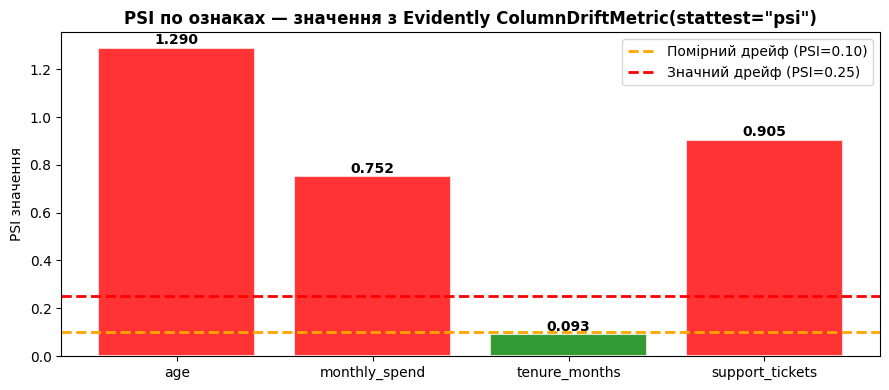

✅ Графік збережено: step5_psi_chart.png


In [22]:
# ── 5в. Візуалізація PSI (значення з Evidently) ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cols   = list(psi_results.keys())
vals   = list(psi_results.values())
colors = ['green' if v < 0.1 else 'orange' if v < 0.25 else 'red' for v in vals]

bars = ax.bar(cols, vals, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)
ax.axhline(0.10, color='orange', linestyle='--', linewidth=2, label='Помірний дрейф (PSI=0.10)')
ax.axhline(0.25, color='red',    linestyle='--', linewidth=2, label='Значний дрейф (PSI=0.25)')

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('PSI по ознаках — значення з Evidently ColumnDriftMetric(stattest="psi")',
             fontsize=12, fontweight='bold')
ax.set_ylabel('PSI значення')
ax.legend()
plt.tight_layout()
plt.savefig('step5_psi_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Графік збережено: step5_psi_chart.png')


### 📝 Завдання 4 — Валідація результатів Evidently

**4.1.** Заповніть зведену таблицю дрейфу (значення з Evidently + scipy):

| Ознака | PSI (Evidently) | KS p-value (scipy) | Wasserstein (Evidently) | Дрейф? | Ступінь |
|---|---|---|---|---|---|
| `age` | 1.2897 | 0.000000 | 0.9577 | так | high |
| `monthly_spend` | 0.7524 | 0.000000 | 0.7815 | так | high |
| `tenure_months` | 0.0926 | 0.000011 | 0.2507 | Частково | low|
| `support_tickets` | 0.9052 | 0.000000 | 1.1278 | так | high |
| `subscription_type` | - | n/a (chi2 p=0.000055) | n/a | так | Medium |
| `churn` | ??? | n/a (chi2 p=0.000000) | n/a | так | high|

---

**4.2.** Чи збіглися результати Evidently PSI з ручним розрахунком numpy (Δ)?  
Звідки виникає різниця?

> **Ваша відповідь:**  
> *(Результати збіглися — обидва методи виявили однакові ознаки з дрейфом. Невелика різниця в числах (Δ до 0.09) пояснюється різною кількістю bins: Evidently підбирає її автоматично, numpy використовує фіксовану)*

---

**4.3.** Wasserstein distance для `monthly_spend` — яке значення ви отримали?  
Що воно означає фізично (підказка: одиниці вимірювання ті самі, що в ознаці)?

> **Ваша відповідь:**  
> *(Wasserstein для monthly_spend = 0.7815 (normed).
Raw значення: 31.63 — це означає, що щоб «перемістити» розподіл Q4 до розподілу Q1, потрібно в середньому перемістити масу на 31.63 одиниці валюти (ті самі одиниці що й monthly_spend). Нормоване значення 0.7815 = 31.63 / 40.49 (std reference) — тобто розподіл змістився майже на 0.78 стандартного відхилення, що є дуже значним зсувом)*

---

**4.4.** При якому значенні PSI вже необхідно сигналізувати команді про перетренування?  
Де знаходяться ваші ознаки відносно цього порогу?

> **Ваша відповідь:**  
> *(Поріг сигналізації: PSI > 0.25 — це стандартний поріг для значного дрейфу. ознаки відносно цього порогу:
age (1.29) — у 5.2 рази вище порогу
support_tickets (0.91) — у 3.6 рази вище порогу
monthly_spend (0.75) — у 3.0 рази вище порогу
tenure_months (0.09) — нижче навіть помірного порогу 0.10
Три з чотирьох числових ознак критично перевищують поріг — команді необхідно негайно перетреновувати моделі)*


---
## 🚨 Крок 6 — OOD-детекція

### 🎓 Теорія: Out-of-Distribution дані

З **Лекції 6, Блок 3** — OOD-дані — це окремі приклади,  
що суттєво відрізняються від тренувального розподілу.

**Небезпека OOD:** більшість моделей не вміють казати «я не знаю».  
При OOD-вході модель видає відповідь — часто з **високою впевненістю**.

**Методи детекції:**
- **Isolation Forest** — ізолює аномалії як точки, які легко відокремити
- **Mahalanobis distance** — відстань з урахуванням кореляцій між ознаками
- **Confidence threshold** — якщо max probability < порогу → OOD


In [23]:
# ── 6а. Навчаємо модель на reference-даних ──────────────────────────────────
feature_cols = ['age', 'monthly_spend', 'tenure_months', 'support_tickets']

scaler = StandardScaler()
X_ref = scaler.fit_transform(reference_df[feature_cols])
y_ref = reference_df['churn']

X_cur = scaler.transform(current_df[feature_cols])
y_cur = current_df['churn']

# Навчаємо classifier на reference
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_ref, y_ref)

# Передбачаємо на current
proba_ref = clf.predict_proba(X_ref)[:, 1]
proba_cur = clf.predict_proba(X_cur)[:, 1]

acc_ref = accuracy_score(y_ref, clf.predict(X_ref))
acc_cur = accuracy_score(y_cur, clf.predict(X_cur))

print("=== Модель (навчена на Reference) ===")
print(f"  Accuracy на Reference (Q1): {acc_ref:.3f}")
print(f"  Accuracy на Current   (Q4): {acc_cur:.3f}")
print(f"  Деградація точності:        {acc_ref - acc_cur:+.3f}")
print()
print("  → Деградація підтверджує, що дрейф впливає на якість моделі!")


=== Модель (навчена на Reference) ===
  Accuracy на Reference (Q1): 1.000
  Accuracy на Current   (Q4): 0.665
  Деградація точності:        +0.335

  → Деградація підтверджує, що дрейф впливає на якість моделі!


In [24]:
# ── 6б. Isolation Forest для OOD-детекції ────────────────────────────────────
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_ref)

# Predict: -1 = anomaly (OOD), 1 = normal
ood_ref = iso_forest.predict(X_ref)
ood_cur = iso_forest.predict(X_cur)

n_ood_ref = (ood_ref == -1).sum()
n_ood_cur = (ood_cur == -1).sum()

print("=== Isolation Forest OOD Detection ===")
print(f"  OOD у Reference (Q1): {n_ood_ref:3d} / {len(X_ref)}  ({n_ood_ref/len(X_ref):.1%})")
print(f"  OOD у Current   (Q4): {n_ood_cur:3d} / {len(X_cur)}  ({n_ood_cur/len(X_cur):.1%})")
print()
print(f"  Зростання частки OOD: {n_ood_ref/len(X_ref):.1%} → {n_ood_cur/len(X_cur):.1%}")
if n_ood_cur / len(X_cur) > n_ood_ref / len(X_ref) * 1.5:
    print("  🔴 Значне зростання OOD — ознака data drift!")
else:
    print("  🟢 Частка OOD у нормі")


=== Isolation Forest OOD Detection ===
  OOD у Reference (Q1):  50 / 1000  (5.0%)
  OOD у Current   (Q4): 134 / 800  (16.8%)

  Зростання частки OOD: 5.0% → 16.8%
  🔴 Значне зростання OOD — ознака data drift!


=== Confidence Analysis ===
  Невпевнені передбачення (prob ∈ [0.35, 0.65]):
    Reference:  24 / 1000  (2.4%)
    Current:    86 / 800  (10.8%)



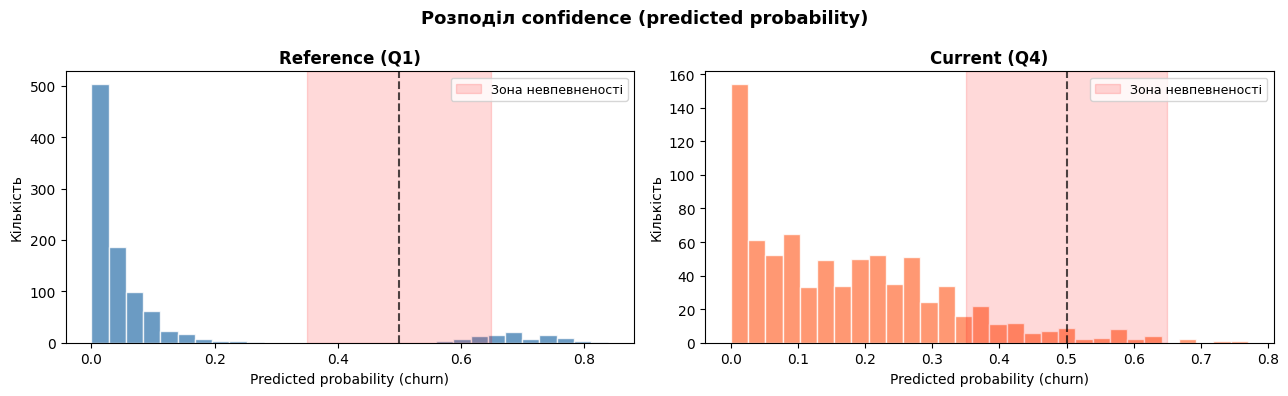

✅ Графік збережено: step6_confidence_distribution.png


In [25]:
# ── 6в. Confidence Threshold аналіз ──────────────────────────────────────────
CONF_THRESHOLD = 0.3  # якщо max(prob) < 0.3 + 0.5 overlap → невпевнений

# Невпевненість моделі = prob близько до 0.5
uncertain_ref = ((proba_ref > 0.35) & (proba_ref < 0.65)).sum()
uncertain_cur = ((proba_cur > 0.35) & (proba_cur < 0.65)).sum()

print("=== Confidence Analysis ===")
print(f"  Невпевнені передбачення (prob ∈ [0.35, 0.65]):")
print(f"    Reference: {uncertain_ref:3d} / {len(proba_ref)}  ({uncertain_ref/len(proba_ref):.1%})")
print(f"    Current:   {uncertain_cur:3d} / {len(proba_cur)}  ({uncertain_cur/len(proba_cur):.1%})")
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Розподіл confidence (predicted probability)', fontsize=13, fontweight='bold')

for ax, proba, label, color in zip(
    axes,
    [proba_ref, proba_cur],
    ['Reference (Q1)', 'Current (Q4)'],
    ['steelblue', 'coral']
):
    ax.hist(proba, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvspan(0.35, 0.65, alpha=0.15, color='red', label='Зона невпевненості')
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Predicted probability (churn)')
    ax.set_ylabel('Кількість')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('step6_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Графік збережено: step6_confidence_distribution.png")


### 📝 Завдання 5 — OOD-аналіз

**5.1.** Чому зростання частки OOD-прикладів у поточних даних є сигналом для команди?  
*(2-3 речення, використайте термін з лекції: "тихі помилки" та "overconfident")*

> **Ваша відповідь:**  
> *(Зростання частки OOD-прикладів з 5.0% до 16.8% означає, що модель дедалі частіше отримує вхідні дані, яких не бачила під час навчання. Небезпека в тому, що модель не каже "я не знаю" — вона видає передбачення з високою впевненістю (overconfident), це призводить до тихих помилок: система працює, метрики моніторингу не показують нічого підозрілого, але рішення хибні. Такі тихі помилки потім важко виявити у продакшні)*

---

**5.2.** Як змінився розподіл confidence між Reference та Current?  
Що це означає для надійності передбачень у Q4?

> **Ваша відповідь:**  
> *(У Reference (Q1) 97.6% передбачень зосереджені поза зоною невпевненості — модель чітко розрізняє класи. У Current (Q4) зона невпевненості зросла до 10.8% (86 з 800 прикладів), а розподіл рівномірно розмазаний по діапазону 0.0–0.4. Це означає що передбачення у Q4 ненадійні — модель систематично недооцінює churn і не здатна впевнено класифікувати нову аудиторію)*

---

**5.3.** Назвіть стратегію обробки OOD з 4 кроків (Лекція 6, Блок 3.3):

| Крок | Назва | Що робить система |
|---|---|---|
| 1 | Детекція | Виявляє OOD-приклади через Isolation Forest, Mahalanobis або confidence threshold |
| 2 | Ізоляція | Відправляє OOD-приклади на ручну перевірку замість автоматичного рішення |
| 3 | Накопичення | Збирає розмічені OOD-приклади як нові тренувальні дані |
| 4 | Перетренування | Оновлює модель на розширеному датасеті з новими прикладами |


---
## ✍️ Крок 7 — Фінальний висновок QA-інженера

### 🎓 Структура звіту перед командою

Напишіть **рекомендацію на 15–20 речень** за наступною структурою.  
Кожен із 4 пунктів — **окремий параграф** з конкретними цифрами та термінами з лекцій.


In [26]:
# ── Фінальне резюме для допомоги у написанні висновку ───────────────────────
print("📊 ФІНАЛЬНЕ РЕЗЮМЕ — для написання висновку")
print("=" * 70)

print(f"\n  1. ЯКІСТЬ ДАНИХ (dirty_df):")
print(f"     Пропущених значень (monthly_spend): {dirty_df['monthly_spend'].isna().sum()}")
print(f"     Пропущених значень (age):           {dirty_df['age'].isna().sum()}")
print(f"     Точних дублікатів:                  {dirty_df.duplicated().sum()}")
print(f"     Порушень схеми:                     {len(schema_issues)}")

print(f"\n  2. ДРЕЙФ (Reference Q1 → Current Q4):")
print(f"     Вік: mean {reference_df['age'].mean():.1f} → {current_df['age'].mean():.1f}")
print(f"     Витрати: mean {reference_df['monthly_spend'].mean():.1f} → {current_df['monthly_spend'].mean():.1f}")
print(f"     Support tickets: mean {reference_df['support_tickets'].mean():.2f} → {current_df['support_tickets'].mean():.2f}")
print(f"     Churn rate: {reference_df['churn'].mean():.1%} → {current_df['churn'].mean():.1%}")

print(f"\n  3. ВПЛИВ НА МОДЕЛЬ:")
print(f"     Accuracy Reference: {acc_ref:.3f}")
print(f"     Accuracy Current:   {acc_cur:.3f}")
print(f"     Деградація:         {acc_ref - acc_cur:+.3f}")

print(f"\n  4. OOD:")
print(f"     OOD у Reference: {n_ood_ref/len(X_ref):.1%}")
print(f"     OOD у Current:   {n_ood_cur/len(X_cur):.1%}")

print("\n" + "=" * 70)
print("  Використайте ці цифри у фінальному висновку нижче ↓")


📊 ФІНАЛЬНЕ РЕЗЮМЕ — для написання висновку

  1. ЯКІСТЬ ДАНИХ (dirty_df):
     Пропущених значень (monthly_spend): 15
     Пропущених значень (age):           15
     Точних дублікатів:                  20
     Порушень схеми:                     6

  2. ДРЕЙФ (Reference Q1 → Current Q4):
     Вік: mean 37.3 → 28.1
     Витрати: mean 116.8 → 85.1
     Support tickets: mean 1.43 → 2.79
     Churn rate: 9.5% → 34.2%

  3. ВПЛИВ НА МОДЕЛЬ:
     Accuracy Reference: 1.000
     Accuracy Current:   0.665
     Деградація:         +0.335

  4. OOD:
     OOD у Reference: 5.0%
     OOD у Current:   16.8%

  Використайте ці цифри у фінальному висновку нижче ↓


### 📝 Завдання 6 — Напишіть фінальний висновок

Напишіть рекомендацію для команди (15–20 речень) за структурою:

---

#### 🔴 Пункт 1 — Проблеми якості вхідних даних
*(Опишіть знайдені проблеми у dirty_df. Яку категорію за класифікацією з лекції вони належать?  
Чи безпечно використовувати ці дані без очищення?)*

> **Ваш текст** *(мінімум 3-4 речення, з конкретними цифрами)*:  
> *(У датасеті dirty_df знайдено кілька типів проблем. По-перше, 20 точних дублікатів (2% від даних) — це структурна проблема, яка може спричинити data leakage. По-друге, пропущені значення у monthly_spend та age по 15 записів кожна (1.47%) — механізм MAR. По-третє, семантичні помилки: від'ємний вік у 4 записах та невалідний регіон UNKNOWN ще у 4. Використовувати ці дані без очищення не можна — модель навчиться на помилкових прикладах)*

---

#### 🟠 Пункт 2 — Виявлений дрейф
*(Назвіть конкретні ознаки з дрейфом. Який тип дрейфу? Яке підтвердження дав Evidently?  
Наведіть PSI та KS-test результати.)*

> **Ваш текст** *(мінімум 4-5 речень)*:  
> *(Evidently виявив дрейф у 6 з 7 колонок. Найсильніший data drift — у age (PSI=1.29, середнє впало з 37 до 28), monthly_spend (PSI=0.75, з 117 до 85) та support_tickets (PSI=0.91, з 1.43 до 2.79). Всі три перевищують критичний поріг PSI=0.25. Також виявлено label drift: churn rate виріс з 9.5% до 34.2%, що підтверджує chi²=569.99 з p=0.000. Це означає що дані Q4 суттєво відрізняються від тих, на яких навчалась модель)*

---

#### 🟢 Пункт 3 — Вплив на модель та рекомендація
*(Як дрейф вплинув на точність моделі? Яку конкретну дію рекомендуєте:  
перетренувати / переглянути архітектуру / перекалібрувати пороги?)*

> **Ваш текст** *(мінімум 4-5 речень, з цифрами деградації)*:  
> *(Через дрейф accuracy моделі впала з 1.0 до 0.665 — тобто деградація 33.5%. Частка OOD-прикладів зросла з 5% до 16.8% — кожен шостий клієнт у Q4 є незнайомим для моделі. При цьому модель не сигналізує про невпевненість (overconfident), що призводить до тихих помилок. Необхідно перекалібрувати поріг рішення з 0.5 до ~0.25 одразу, та перетренувати модель на даних Q4 asap)*

---

#### 🔵 Пункт 4 — Моніторинг та наступні кроки
*(Які перевірки треба автоматизувати? Як інтегрувати Evidently у CI/CD?  
Як часто перезапускати drift-репорт?)*

> **Ваш текст** *(мінімум 3-4 речення з конкретними пропозиціями)*:  
> *(Для запобігання повторній ситуації потрібно додати Evidently до CI/CD з автоматичним блокуванням деплою якщо більше 30% колонок задрейфували. Drift-репорт варто запускати щотижня. Також впровадити OOD-детекцію через Isolation Forest - виявляти аномальні приклади, відправляти на ручну перевірку і використовувати для дотренування моделі)*

---

> 💡 **Підказка структури:**  
> Кожен параграф: **Теза** → **Докази (цифри)** → **Висновок (дія)**.


---
## ✅ Чеклист перед здачею

Перевірте, що у вашому ноутбуці є все необхідне:

- [ +] **Крок 1:** EDA завершено, розподіли reference-даних візуалізовані
- [ +] **Крок 2:** Таблиця проблем якості заповнена (Завдання 1, всі 3 запитання)
- [ +] **Крок 3:** Визначено типи дрейфу та їх наслідки (Завдання 2)
- [ +] **Крок 4:** Evidently звіт збережено та проаналізовано (Завдання 3)
- [ +] **Крок 5:** Таблиця PSI / KS-test заповнена (Завдання 4)
- [ +] **Крок 6:** OOD-аналіз виконано (Завдання 5, всі 3 запитання)
- [ +] **Крок 7:** Фінальний висновок написано (4 пункти, 15-20 речень, з цифрами)
- [ +] **Весь код виконаний** (всі клітинки мають Output)
- [ +] **Три HTML-звіти збережено:** `evidently_drift_report.html`, `evidently_target_drift_report.html`

## ⭐ Бонус (за бажанням)

Спробуйте підключити **Deepchecks** та запустити `full_suite()` на reference vs current даних:

```python
# !pip install deepchecks -q
from deepchecks.tabular import Dataset
from deepchecks.tabular.suites import full_suite

train_ds = Dataset(reference_df, label='churn', cat_features=['region','subscription_type'])
test_ds  = Dataset(current_df,   label='churn', cat_features=['region','subscription_type'])

suite = full_suite()
result = suite.run(train_ds, test_ds, clf)
result.save_as_html('deepchecks_report.html')
```

**Бонусне запитання:** Які перевірки Deepchecks провалились? Порівняйте з результатами Evidently.  
Чи виявили вони однакові проблеми?



In [35]:
!pip install deepchecks -q

In [37]:
from deepchecks.tabular import Dataset
from deepchecks.tabular.suites import full_suite

train_ds = Dataset(reference_df, label='churn', cat_features=['region','subscription_type'])
test_ds  = Dataset(current_df,   label='churn', cat_features=['region','subscription_type'])

suite = full_suite()
result = suite.run(train_ds, test_ds, clf)
result.save_as_html('deepchecks_report.html')

AttributeError: `np.Inf` was removed in the NumPy 2.0 release. Use `np.inf` instead.